# Range of GPS interference in Norway and Northern Finland

In [1]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from shapely.geometry import Polygon, LineString, Point

Get the global list of airports used for openflights.org. This is made available under the [Open Database License](https://opendatacommons.org/licenses/odbl/1-0/).

In [2]:
airports_path=\
'https://raw.githubusercontent.com/jpatokal/openflights/refs/heads/master/data/airports.dat'
airports_df=pd.read_csv(airports_path,
                        header=None,
                        names=['Airport_ID','airport_name','city','country',
                               'iata','icao','lat','lon','altitude','Timezone',
                               'DST','Tz','type','source'],
                        na_values='\\N',
                        on_bad_lines='warn')

Article from Barents observer lists Finnmark airports with problematic GPS performance.
https://www.thebarentsobserver.com/security/russian-jamming-is-now-messing-up-gps-signals-for-norwegian-aviation-practically-every-day/163663

> GPS jamming reports are coming from pilots on the airliners SAS, Norwegian and Widerøe as well as civilian air ambulances flying in and out of Kirkenes airport and the smaller airports along the coast of Finnmark, like Vadsø, Vardø, Båtsfjord, Berlevåg and Mehamn.

Note that the Norwegian placenames have special non-ascii characters.

In [3]:
airports_df[airports_df.country=='Norway']

,Airport_ID,airport_name,city,country,iata,icao,lat,lon,altitude,Timezone,DST,Tz,type,source
621,630,Ålesund Airport,Alesund,Norway,AES,ENAL,62.562500,6.119700,69,1.0,E,Europe/Oslo,airport,OurAirports
622,631,Andøya Airport,Andoya,Norway,ANX,ENAN,69.292503,16.144199,43,1.0,E,Europe/Oslo,airport,OurAirports
623,632,Alta Airport,Alta,Norway,ALF,ENAT,69.976097,23.371700,9,1.0,E,Europe/Oslo,airport,OurAirports
624,633,Bømoen Airport,Voss,Norway,NaN,ENBM,60.638901,6.501500,300,1.0,E,Europe/Oslo,airport,OurAirports
625,634,Brønnøysund Airport,Bronnoysund,Norway,BNN,ENBN,65.461098,12.217500,25,1.0,E,Europe/Oslo,airport,OurAirports
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5841,7872,Ringebu Airfield Frya,Frya,Norway,NaN,ENRI,61.545441,10.061588,571,1.0,E,Europe/Oslo,airport,OurAirports
6534,9255,Rakkestad Astorp Airport,Rakkestad,Norway,NaN,ENRK,59.397499,11.346900,400,1.0,E,Europe/Oslo,airport,OurAirports
6712,10080,Kautokeino Air Base,Kautokeino,Norway,QKX,ENKA,69.040298,23.034000,1165,1.0,U,NaN,airport,OurAirports
7490,13416,Pyramiden Heliport,Pyramiden,Norway,NaN,ENPY,78.652322,16.337208,6,1.0,E,NaN,airport,OurAirports


Note that in the airports data, the airport name has the special characters, whereas the city names are in the nearest ascii characters.

In [4]:
affected_list='Kirkenes|Vadsø|Vardø|Båtsfjord|Berlevåg|Mehamn'
norway_df=airports_df.query("airport_name.str.contains('"+affected_list+"')")

In [5]:
def df2gdf(in_df):
    return geopandas.GeoDataFrame(in_df, 
                       geometry=geopandas.points_from_xy(in_df.longitude,
                                                         in_df.latitude),
                       crs="EPSG:4326")

In [6]:
norway_gdf=df2gdf(norway_df.rename(columns={'lon':'longitude','lat':'latitude'}))

In [7]:
local_utm=norway_gdf.estimate_utm_crs(datum_name='WGS 84')

In [8]:
geolocator = Nominatim(user_agent="stelios-c GPS analysis")
murmansk_location = geolocator.geocode("Murmansk, Russian Federation")
kaliningrad_location = geolocator.geocode("Kaliningrad, Russian Federation")
st_petersburg_location = geolocator.geocode("St. Petersburg, Russian Federation")

In [9]:
murmansk_location

Location(Мурманск, городской округ Мурманск, Мурманская область, Северо-Западный федеральный округ, Россия, (68.970665, 33.07497, 0.0))

In [10]:
kaliningrad_location

Location(городской округ Калининград, Калининградская область, Северо-Западный федеральный округ, Россия, (54.7046485, 20.4565666, 0.0))

In [11]:
st_petersburg_location 

Location(Санкт-Петербург, Северо-Западный федеральный округ, Россия, (59.9606739, 30.1586551, 0.0))

In [12]:
def location2df(location,name):
    return pd.DataFrame({'port':name,
                  'latitude':float(location.latitude),
                  'longitude':float(location.longitude)},
                  index=[0])

In [13]:
df2gdf(location2df(murmansk_location,'murmansk'))

,port,latitude,longitude,geometry
0,murmansk,68.970665,33.07497,POINT (33.07497 68.97066)


In [14]:
countries="https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
world = (geopandas
         .read_file(countries)
         .clip([3, 50, 42, 72]).dropna(axis='columns',how='all')
        )

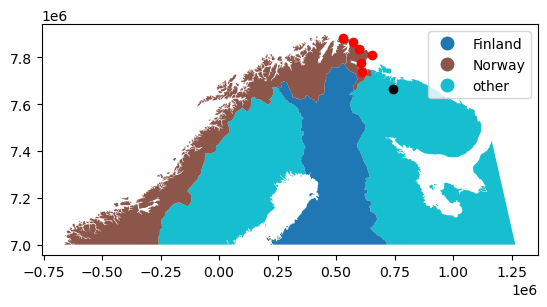

In [15]:
ax = (world
 .assign(
     colour= world.SOVEREIGNT.where(world.SOVEREIGNT.str.match('Finland') | 
                                    world.SOVEREIGNT.str.match('Norway') ,
                                    'other')
 )
).to_crs(local_utm).clip([-1_000_000, 7_000_000, 1_500_000, 8_000_000]).plot(column='colour',legend=True)
norway_gdf.to_crs(local_utm).plot(ax=ax,color='red')
df2gdf(location2df(murmansk_location,'murmansk')).to_crs(local_utm).plot(ax=ax,color='black')
plt.show()

Map showing the Norwegian airports suffering from GNSS interference as red dots, and the Russian port which is a possible source of interference, overlayed on a map of the border area between Norway, Russia, Sweden and Finland.  

In [16]:
#norway_gdf.explore()

Recreate the northern circle from fig 1 in https://traficom.fi/en/news/interference-affecting-mobile-communications-and-satellite-navigation-services-continues-finland using GeoPandas

<Axes: xlabel='icao', ylabel='r (m)'>

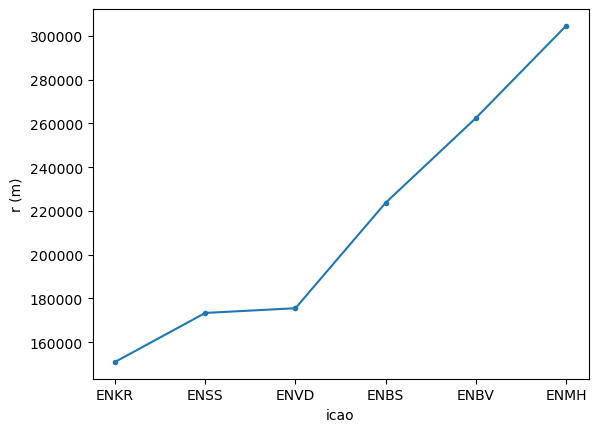

In [23]:
(norway_gdf
 .set_index('icao')
 .to_crs(local_utm)
 .geometry
 .apply(lambda df: df.distance(df2gdf(location2df(murmansk_location,'murmansk')).to_crs(local_utm).geometry))
 .sort_values(0)
 .plot(marker='.',ylabel='r (m)',legend=False)
)


<Axes: xlabel='icao', ylabel='$ { r^-2 } (m^{-2}) $'>

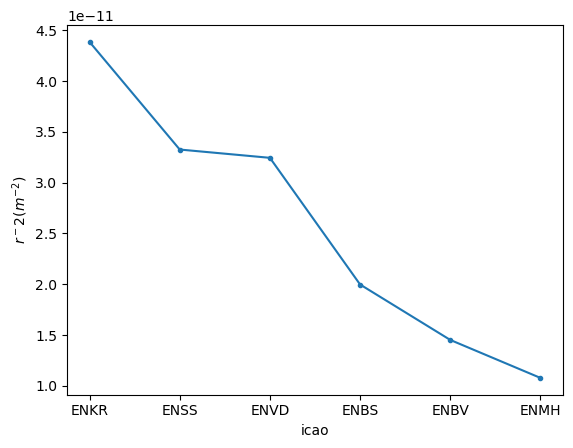

In [22]:
(norway_gdf
 .set_index('icao')
 .to_crs(local_utm)
 .geometry
 .apply(lambda df: (df.distance(df2gdf(location2df(murmansk_location,'murmansk')).to_crs(local_utm).geometry))**-2 )
 .sort_values(0,ascending=False)
 .plot(marker='.',ylabel='$ { r^-2 } (m^{-2}) $',legend=False)
)


In [24]:
buffer_radius=(norway_gdf
 .set_index('icao')
 .to_crs(local_utm)
 .geometry
 .apply(lambda df: df.distance(df2gdf(location2df(murmansk_location,'murmansk')).to_crs(local_utm).geometry))
 .max()
)
buffer_radius

0    304599.867035
dtype: float64

This is a lower bound for the horizontal component of the range of interference. The upper bound would be between this and the next Norwegian airport further away from the source. 

In [25]:
murmansk_buff_gdf= df2gdf(location2df(murmansk_location,'murmansk')).to_crs(local_utm).buffer(buffer_radius)

In [26]:
murmansk_buff_gdf

0    POLYGON ((1047548.651 7663127.233, 1046081.92 ...
dtype: geometry

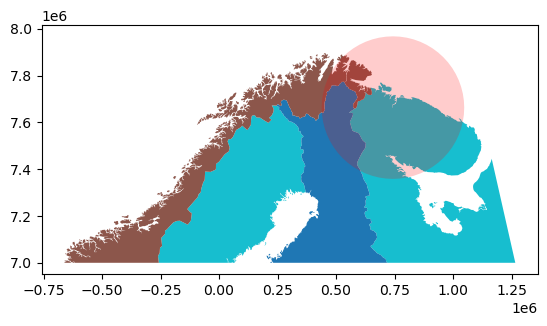

In [27]:
ax = (world
 .assign(
     colour= world.SOVEREIGNT.where(world.SOVEREIGNT.str.match('Finland') | 
                                    world.SOVEREIGNT.str.match('Norway') ,
                                    'other')
 )
).to_crs(local_utm).clip([-1_000_000, 7_000_000, 1_500_000, 8_000_000]).plot(column='colour')
murmansk_buff_gdf.plot(ax=ax,color='red',alpha=0.2)
plt.show()

In [28]:
#murmansk_buff_gdf.explore()

In [37]:
df2gdf(location2df(kaliningrad_location,'kaliningrad')).to_crs(local_utm).buffer(buffer_radius)

0    POLYGON ((383262.705 6081598.387, 381795.974 6...
dtype: geometry

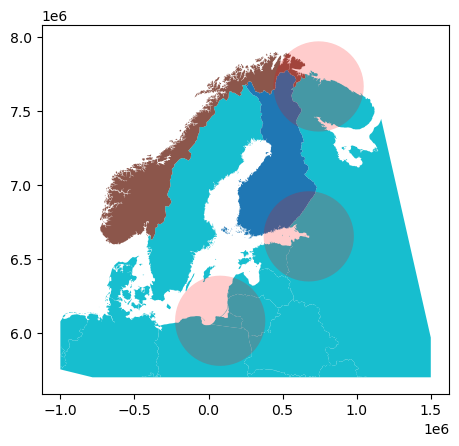

In [38]:
ax = (world
 .assign(
     colour= world.SOVEREIGNT.where(world.SOVEREIGNT.str.match('Finland') | 
                                    world.SOVEREIGNT.str.match('Norway') ,
                                    'other')
 )
).to_crs(local_utm).clip([-1_000_000, 5_700_000, 1_500_000, 8_000_000]).plot(column='colour')
murmansk_buff_gdf.plot(ax=ax,color='red',alpha=0.2)
df2gdf(location2df(kaliningrad_location,'kaliningrad')).to_crs(local_utm).buffer(buffer_radius).plot(ax=ax,color='red',alpha=0.2)
df2gdf(location2df(st_petersburg_location,'st_petersburg')).to_crs(local_utm).buffer(buffer_radius).plot(ax=ax,color='red',alpha=0.2)
plt.show()

the range of the baltic interference is assumed to be bigger than the range of the arctic one? or we have a projection bug? Or Traficom used a Google maps screenshot with whatever projection Google use, and did the circles in "MS Paint"?

In [39]:
geodesic(kaliningrad_location.point,st_petersburg_location.point)

Distance(825.5398184543196)

In [40]:
finland_gdf=df2gdf(airports_df[airports_df.country=='Finland'].rename(columns={'lon':'longitude','lat':'latitude'}))

In [47]:
finland_gdf

,Airport_ID,airport_name,city,country,iata,icao,latitude,longitude,altitude,Timezone,DST,Tz,type,source,geometry
413,417,Enontekio Airport,Enontekio,Finland,ENF,EFET,68.362602,23.424299,1005,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (23.4243 68.3626)
414,418,Eura Airport,Eura,Finland,NaN,EFEU,61.116100,22.201401,259,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (22.2014 61.1161)
415,419,Halli Airport,Halli,Finland,KEV,EFHA,61.856039,24.786686,479,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (24.78669 61.85604)
416,420,Helsinki Malmi Airport,Helsinki,Finland,HEM,EFHF,60.254601,25.042801,57,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (25.0428 60.2546)
417,421,Helsinki Vantaa Airport,Helsinki,Finland,HEL,EFHK,60.317200,24.963301,179,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (24.9633 60.3172)
418,422,Hameenkyro Airport,Hameenkyro,Finland,NaN,EFHM,61.689701,23.073700,449,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (23.0737 61.6897)
419,423,Hanko Airport,Hanko,Finland,NaN,EFHN,59.848900,23.083599,20,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (23.0836 59.8489)
420,424,Hyvinkää Airfield,Hyvinkaa,Finland,HYV,EFHV,60.654400,24.881100,430,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (24.8811 60.6544)
421,425,Kiikala Airport,Kikala,Finland,NaN,EFIK,60.462502,23.652500,381,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (23.6525 60.4625)
422,426,Immola Airport,Immola,Finland,NaN,EFIM,61.249199,28.903700,338,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (28.9037 61.2492)


In [49]:
#finland_gdf.explore()

In [46]:
finland_gdf.to_crs(local_utm).sjoin(df2gdf(location2df(murmansk_location,'murmansk')).to_crs(local_utm), how='inner',predicate='dwithin',distance=buffer_radius)#.explore


,Airport_ID,airport_name,city,country,iata,icao,latitude_left,longitude_left,altitude,Timezone,DST,Tz,type,source,geometry,index_right,port,latitude_right,longitude_right
424,428,Ivalo Airport,Ivalo,Finland,IVL,EFIV,68.6073,27.4053,481,2.0,E,Europe/Helsinki,airport,OurAirports,POINT (516498.35 7610629.653),0,murmansk,68.970665,33.07497


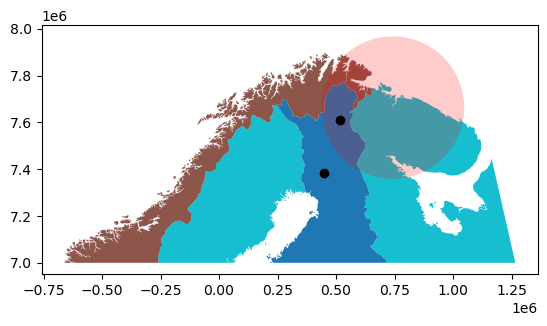

In [51]:
ax = (world
 .assign(
     colour= world.SOVEREIGNT.where(world.SOVEREIGNT.str.match('Finland') | 
                                    world.SOVEREIGNT.str.match('Norway') ,
                                    'other')
 )
).to_crs(local_utm).clip([-1_000_000, 7_000_000, 1_500_000, 8_000_000]).plot(column='colour')
murmansk_buff_gdf.plot(ax=ax,color='red',alpha=0.2)
finland_gdf.query('icao in ("EFIV","EFRO")').to_crs(local_utm).plot(ax=ax,color='black')
plt.show()

Santa's nearest airport at Rovaniemi is safe, interference only affects Ivalo airport.

This analysis is available in my Github repository https://github.com/stelios-c/GPS_analysis